# AI Workforce Displacement — End-to-End Data Engineering Pipeline  
**Scope:** Ingestion → Profiling → Cleaning → Feature Engineering → EDA → Modelling → Export

## Environment Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

import xgboost as xgb
import shap
import missingno as msno

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

SEED = 42
np.random.seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'monospace'
})

PALETTE = 'coolwarm'
print('Environment ready.')

Environment ready.


## 1. Data Ingestion

In [2]:
RAW_PATH = '/kaggle/input/datasets/alitaqishah/ai-workforce-displacement-20202026/ai_workforce_displacement_global_2020_2026.csv'

df_raw = pd.read_csv(RAW_PATH)
print(f'Shape : {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

Shape : (20800, 23)
Columns: ['record_id', 'country', 'iso3_code', 'region', 'income_group', 'year', 'quarter', 'quarter_label', 'industry_sector', 'sector_automation_risk_score', 'gdp_per_capita_usd', 'ai_adoption_index', 'pct_sector_workforce_displaced', 'pct_sector_workforce_new_roles_created', 'net_workforce_change_pct', 'ai_cited_layoff_announcements', 'ai_skill_wage_premium_pct', 'pct_workforce_female', 'pct_displaced_roles_female', 'reskilling_programs_count', 'govt_ai_policy_score_1_to_10', 'ai_tool_adoption_pct', 'data_source_notes']


,record_id,country,iso3_code,region,income_group,year,quarter,quarter_label,industry_sector,sector_automation_risk_score,gdp_per_capita_usd,ai_adoption_index,pct_sector_workforce_displaced,pct_sector_workforce_new_roles_created,net_workforce_change_pct,ai_cited_layoff_announcements,ai_skill_wage_premium_pct,pct_workforce_female,pct_displaced_roles_female,reskilling_programs_count,govt_ai_policy_score_1_to_10,ai_tool_adoption_pct,data_source_notes
0,1,United States,USA,North America,High Income,2020,1,2020-Q1,Technology & Software,0.3820,63514,0.8300,0.0406,0.0348,-0.0058,32,0.3110,0.2800,0.2750,52,6.4000,0.2800,Research-calibrated synthetic data. Grounded i...
1,2,United States,USA,North America,High Income,2020,1,2020-Q1,Finance & Banking,0.6080,63514,0.8170,0.0517,0.0423,-0.0094,51,0.3040,0.4800,0.5110,39,6.5000,0.5590,Research-calibrated synthetic data. Grounded i...
2,3,United States,USA,North America,High Income,2020,1,2020-Q1,Healthcare & Life Sciences,0.1980,63514,0.8160,0.0176,0.0168,-0.0008,4,0.2780,0.7200,0.7070,37,6.8000,0.2020,Research-calibrated synthetic data. Grounded i...


In [3]:
df_raw.dtypes

record_id                                   int64
country                                    object
iso3_code                                  object
region                                     object
income_group                               object
year                                        int64
quarter                                     int64
quarter_label                              object
industry_sector                            object
sector_automation_risk_score              float64
gdp_per_capita_usd                          int64
ai_adoption_index                         float64
pct_sector_workforce_displaced            float64
pct_sector_workforce_new_roles_created    float64
net_workforce_change_pct                  float64
ai_cited_layoff_announcements               int64
ai_skill_wage_premium_pct                 float64
pct_workforce_female                      float64
pct_displaced_roles_female                float64
reskilling_programs_count                   int64


In [4]:
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
record_id,20800.0000,NaN,NaN,NaN,10400.5000,6004.5871,1.0000,5200.7500,10400.5000,15600.2500,20800.0000
country,20800,80,United States,260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iso3_code,20800,80,USA,260,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,20800,12,Europe,5200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_group,20800,4,High Income,8060,NaN,NaN,NaN,NaN,NaN,NaN,NaN
year,20800.0000,NaN,NaN,NaN,2022.7692,1.8874,2020.0000,2021.0000,2023.0000,2024.0000,2026.0000
quarter,20800.0000,NaN,NaN,NaN,2.4231,1.1154,1.0000,1.0000,2.0000,3.0000,4.0000
quarter_label,20800,26,2020-Q1,800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
industry_sector,20800,10,Technology & Software,2080,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sector_automation_risk_score,20800.0000,NaN,NaN,NaN,0.5379,0.1903,0.1510,0.3790,0.5800,0.6980,0.8550


## 2. Data Profiling

In [5]:
print('=== BASIC PROFILE ===')
print(f'Total records    : {len(df_raw):,}')
print(f'Total columns    : {df_raw.shape[1]}')
print(f'Duplicate rows   : {df_raw.duplicated().sum()}')
print(f'Years covered    : {sorted(df_raw["year"].unique())}')
print(f'Unique countries : {df_raw["country"].nunique()}')
print(f'Unique sectors   : {df_raw["industry_sector"].nunique()}')
print(f'Unique regions   : {df_raw["region"].nunique()}')
print(f'Income groups    : {df_raw["income_group"].unique()}')

=== BASIC PROFILE ===
Total records    : 20,800
Total columns    : 23
Duplicate rows   : 0
Years covered    : [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Unique countries : 80
Unique sectors   : 10
Unique regions   : 12
Income groups    : ['High Income' 'Upper Middle Income' 'Lower Middle Income' 'Low Income']


In [6]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df[missing_df.missing_count > 0].sort_values('missing_pct', ascending=False)

,missing_count,missing_pct


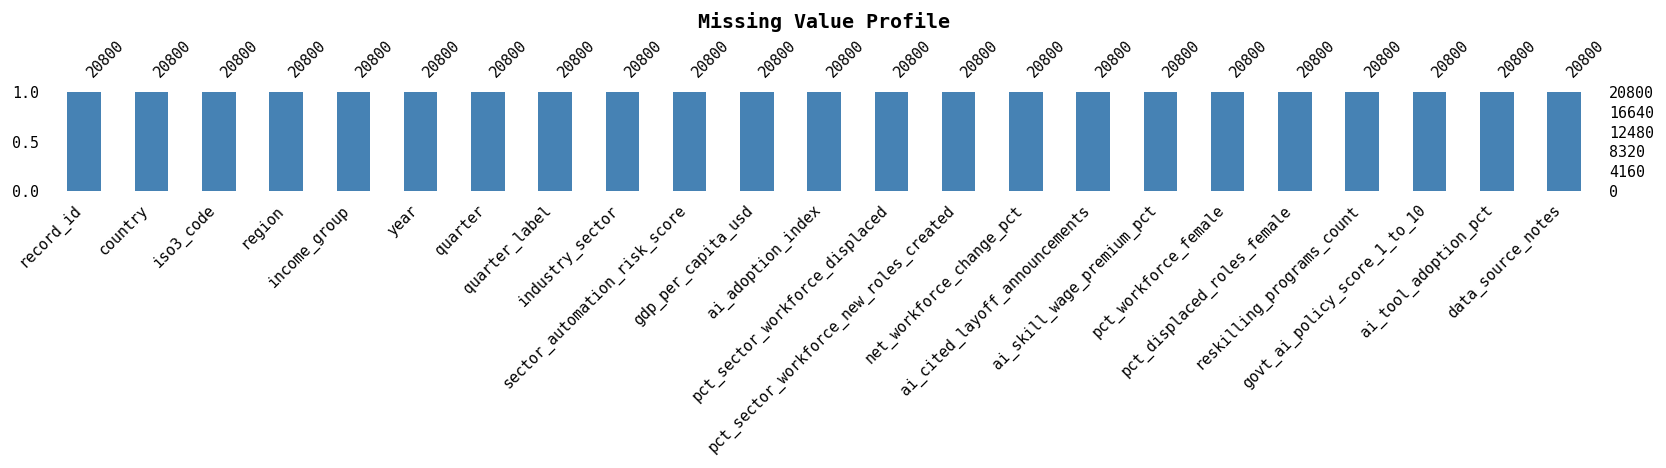

In [7]:
fig, ax = plt.subplots(figsize=(14, 4))
msno.bar(df_raw, ax=ax, color='steelblue', fontsize=9)
ax.set_title('Missing Value Profile', fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
num_cols = df_raw.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_raw.select_dtypes(include='object').columns.tolist()
print('Numeric columns :', num_cols)
print('Categorical columns:', cat_cols)

Numeric columns : ['record_id', 'year', 'quarter', 'sector_automation_risk_score', 'gdp_per_capita_usd', 'ai_adoption_index', 'pct_sector_workforce_displaced', 'pct_sector_workforce_new_roles_created', 'net_workforce_change_pct', 'ai_cited_layoff_announcements', 'ai_skill_wage_premium_pct', 'pct_workforce_female', 'pct_displaced_roles_female', 'reskilling_programs_count', 'govt_ai_policy_score_1_to_10', 'ai_tool_adoption_pct']
Categorical columns: ['country', 'iso3_code', 'region', 'income_group', 'quarter_label', 'industry_sector', 'data_source_notes']


In [9]:
skew_df = df_raw[num_cols].skew().sort_values(ascending=False)
print('Skewness per numeric column:')
print(skew_df)

Skewness per numeric column:
ai_cited_layoff_announcements             1.7910
pct_sector_workforce_new_roles_created    1.7768
pct_sector_workforce_displaced            1.5074
gdp_per_capita_usd                        1.0539
pct_displaced_roles_female                0.6154
reskilling_programs_count                 0.4719
pct_workforce_female                      0.3127
ai_tool_adoption_pct                      0.2788
quarter                                   0.1102
year                                      0.0597
record_id                                 0.0000
govt_ai_policy_score_1_to_10             -0.1669
ai_skill_wage_premium_pct                -0.2046
sector_automation_risk_score             -0.3646
ai_adoption_index                        -0.7103
net_workforce_change_pct                 -1.4218
dtype: float64


## 3. Data Cleaning

In [10]:
df = df_raw.copy()

df.drop(columns=['data_source_notes'], inplace=True)

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

num_fill_cols = [
    'sector_automation_risk_score', 'gdp_per_capita_usd', 'ai_adoption_index',
    'pct_sector_workforce_displaced', 'pct_sector_workforce_new_roles_created',
    'net_workforce_change_pct', 'ai_cited_layoff_announcements',
    'ai_skill_wage_premium_pct', 'pct_workforce_female', 'pct_displaced_roles_female',
    'reskilling_programs_count', 'govt_ai_policy_score_1_to_10', 'ai_tool_adoption_pct'
]

for col in num_fill_cols:
    if df[col].isnull().sum() > 0:
        median_val = df.groupby(['country', 'industry_sector'])[col].transform('median')
        df[col] = df[col].fillna(median_val).fillna(df[col].median())

print(f'Missing after cleaning: {df.isnull().sum().sum()}')
print(f'Shape after cleaning  : {df.shape}')

Missing after cleaning: 0
Shape after cleaning  : (20800, 22)


In [11]:
def cap_outliers_iqr(series, factor=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - factor * iqr, q3 + factor * iqr
    return series.clip(lower, upper)

outlier_targets = [
    'ai_cited_layoff_announcements', 'reskilling_programs_count',
    'pct_sector_workforce_displaced', 'net_workforce_change_pct'
]

for col in outlier_targets:
    df[col] = cap_outliers_iqr(df[col])

print('Outlier capping done.')

Outlier capping done.


In [12]:
assert (df['pct_sector_workforce_displaced'] >= 0).all(), 'Negative displacement found'
assert (df['ai_adoption_index'].between(0, 1)).all(), 'AI adoption out of [0,1]'
assert (df['sector_automation_risk_score'].between(0, 1)).all(), 'Risk score out of [0,1]'
print('Validation checks passed.')

Validation checks passed.


## 4. Feature Engineering

In [13]:
df['displacement_gap'] = df['pct_sector_workforce_displaced'] - df['pct_sector_workforce_new_roles_created']

df['log_gdp_per_capita'] = np.log1p(df['gdp_per_capita_usd'])

df['log_layoff_announcements'] = np.log1p(df['ai_cited_layoff_announcements'])

df['risk_adoption_interaction'] = df['sector_automation_risk_score'] * df['ai_adoption_index']

df['female_displacement_ratio'] = df['pct_displaced_roles_female'] / (df['pct_workforce_female'] + 1e-6)

df['reskilling_per_displacement'] = df['reskilling_programs_count'] / (df['pct_sector_workforce_displaced'] + 1e-6)

df['year_quarter'] = df['year'] + (df['quarter'] - 1) / 4

df['high_risk_sector'] = (df['sector_automation_risk_score'] > 0.6).astype(int)

df['net_change_flag'] = np.where(df['net_workforce_change_pct'] < 0, 'net_loss', 'net_gain')

print('New columns added:')
new_cols = [
    'displacement_gap', 'log_gdp_per_capita', 'log_layoff_announcements',
    'risk_adoption_interaction', 'female_displacement_ratio',
    'reskilling_per_displacement', 'year_quarter', 'high_risk_sector', 'net_change_flag'
]
print(new_cols)
df[new_cols].describe()

New columns added:
['displacement_gap', 'log_gdp_per_capita', 'log_layoff_announcements', 'risk_adoption_interaction', 'female_displacement_ratio', 'reskilling_per_displacement', 'year_quarter', 'high_risk_sector', 'net_change_flag']


,displacement_gap,log_gdp_per_capita,log_layoff_announcements,risk_adoption_interaction,female_displacement_ratio,reskilling_per_displacement,year_quarter,high_risk_sector
count,20800.0000,20800.0000,20800.0000,20800.0000,20800.0000,20800.0000,20800.0000,20800.0000
mean,0.0204,9.2359,4.0013,0.3723,1.0653,810.5089,2023.1250,0.4691
std,0.0151,1.3118,1.0885,0.1606,0.0650,621.0243,1.8750,0.4991
min,-0.0494,6.7799,0.0000,0.0393,0.9643,43.4776,2020.0000,0.0000
25%,0.0091,8.1483,3.2189,0.2321,1.0121,409.0723,2021.5000,0.0000
50%,0.0164,9.2720,4.1589,0.3685,1.0593,625.9242,2023.1250,0.0000
75%,0.0282,10.6098,4.8442,0.5019,1.1056,1003.3396,2024.7500,1.0000
max,0.1055,11.5036,6.0707,0.7751,1.2025,6664.8153,2026.2500,1.0000


In [14]:
cat_encode_cols = ['region', 'income_group', 'industry_sector']
le_dict = {}
for col in cat_encode_cols:
    le = LabelEncoder()
    df[f'{col}_enc'] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

print('Label encoding done for:', cat_encode_cols)

Label encoding done for: ['region', 'income_group', 'industry_sector']


## 5. Exploratory Data Analysis (EDA)

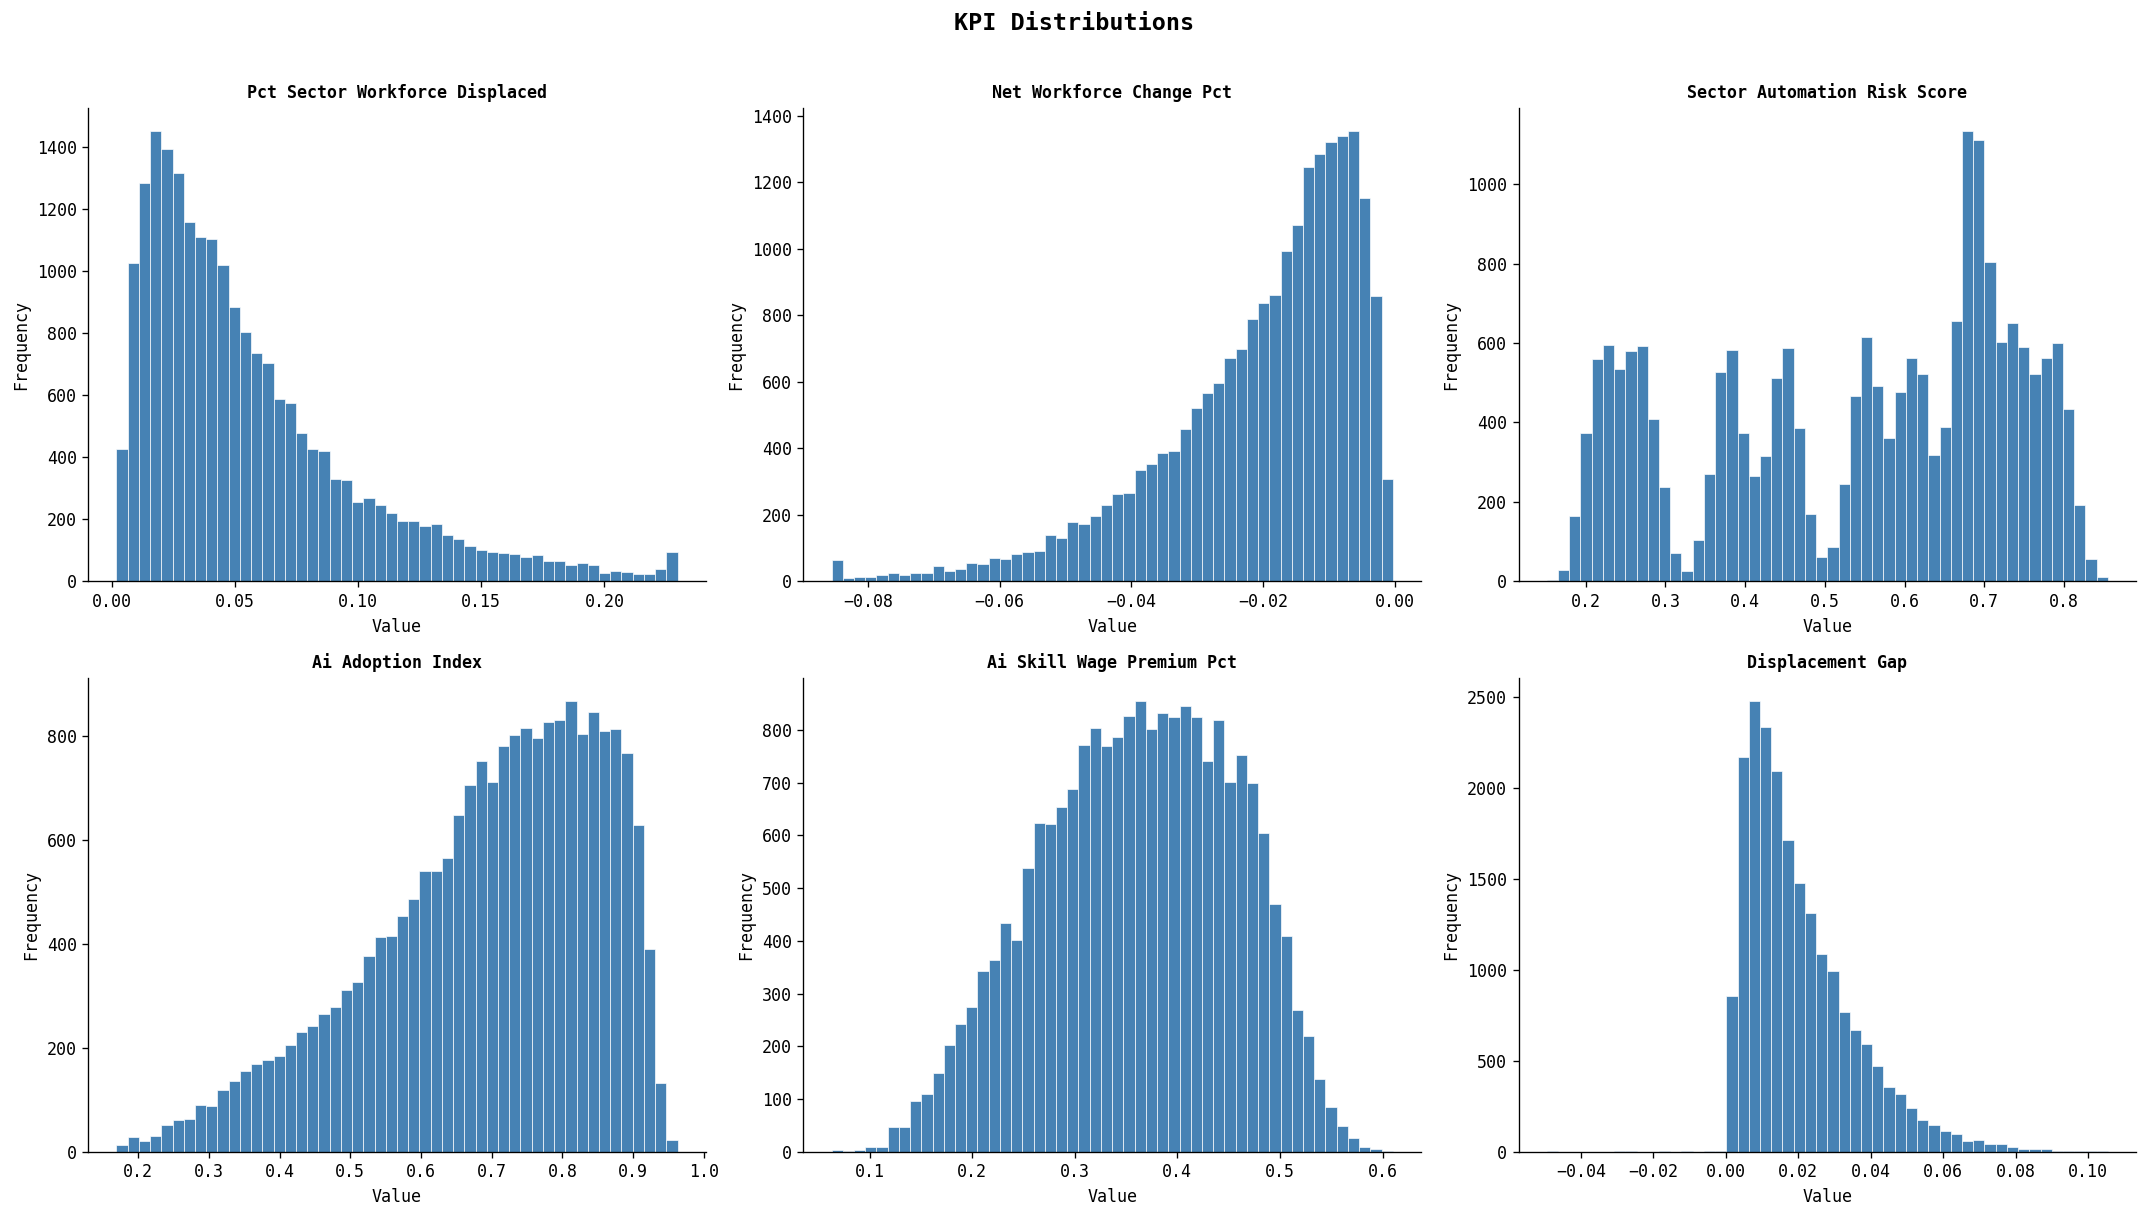

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
kpi_cols = [
    'pct_sector_workforce_displaced', 'net_workforce_change_pct',
    'sector_automation_risk_score', 'ai_adoption_index',
    'ai_skill_wage_premium_pct', 'displacement_gap'
]
for ax, col in zip(axes.flat, kpi_cols):
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
    ax.set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
plt.suptitle('KPI Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

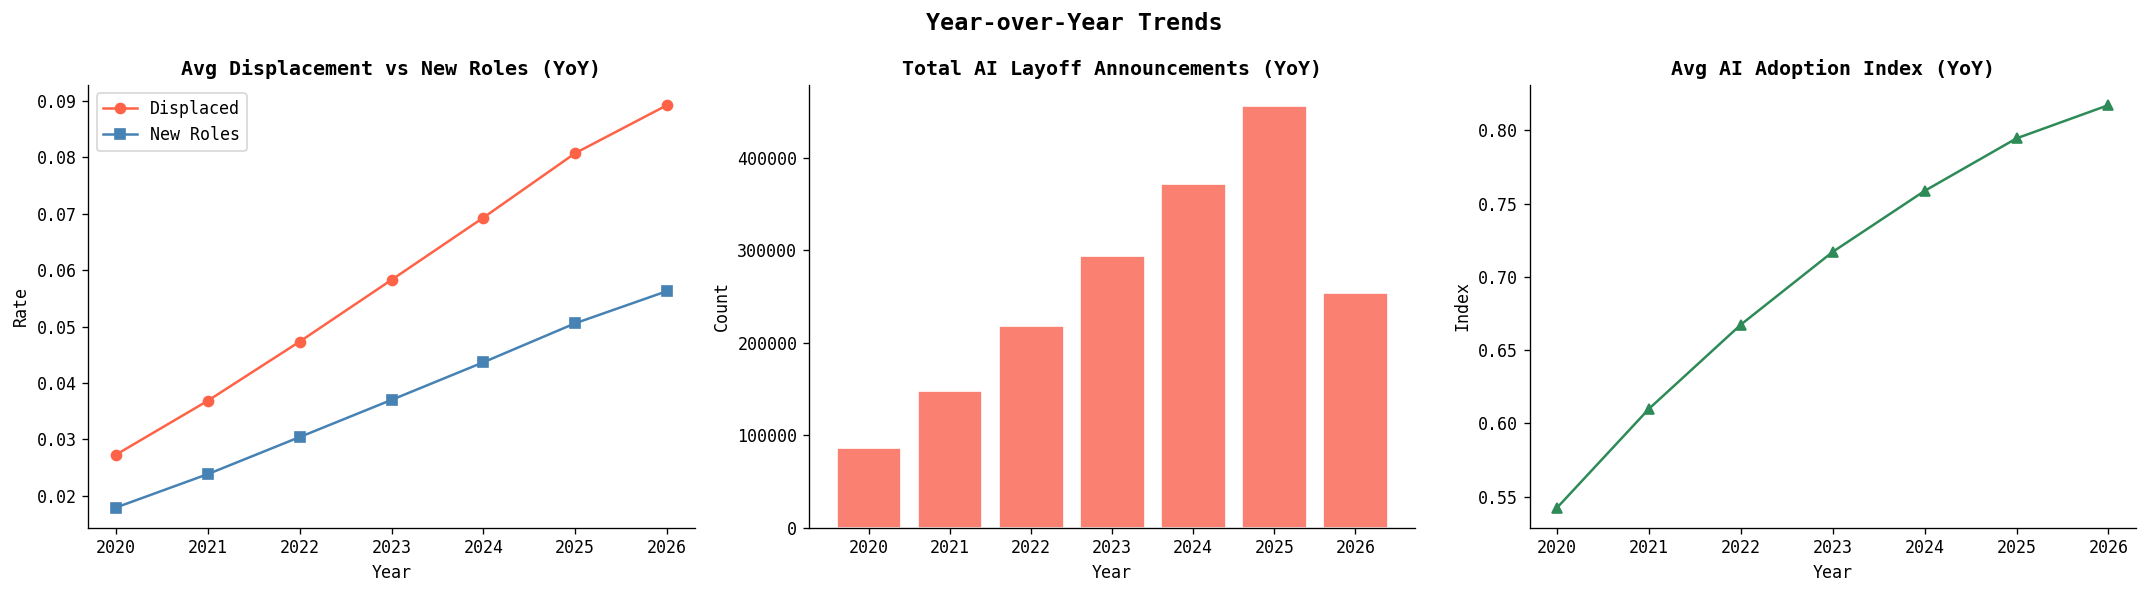

In [16]:
yearly = df.groupby('year').agg(
    avg_displaced=('pct_sector_workforce_displaced', 'mean'),
    avg_new_roles=('pct_sector_workforce_new_roles_created', 'mean'),
    avg_net_change=('net_workforce_change_pct', 'mean'),
    avg_ai_adoption=('ai_adoption_index', 'mean'),
    total_layoffs=('ai_cited_layoff_announcements', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(yearly['year'], yearly['avg_displaced'], marker='o', color='tomato', label='Displaced')
axes[0].plot(yearly['year'], yearly['avg_new_roles'], marker='s', color='steelblue', label='New Roles')
axes[0].set_title('Avg Displacement vs New Roles (YoY)', fontweight='bold')
axes[0].legend()
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Rate')

axes[1].bar(yearly['year'], yearly['total_layoffs'], color='salmon', edgecolor='white')
axes[1].set_title('Total AI Layoff Announcements (YoY)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')

axes[2].plot(yearly['year'], yearly['avg_ai_adoption'], marker='^', color='seagreen')
axes[2].set_title('Avg AI Adoption Index (YoY)', fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Index')

plt.suptitle('Year-over-Year Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

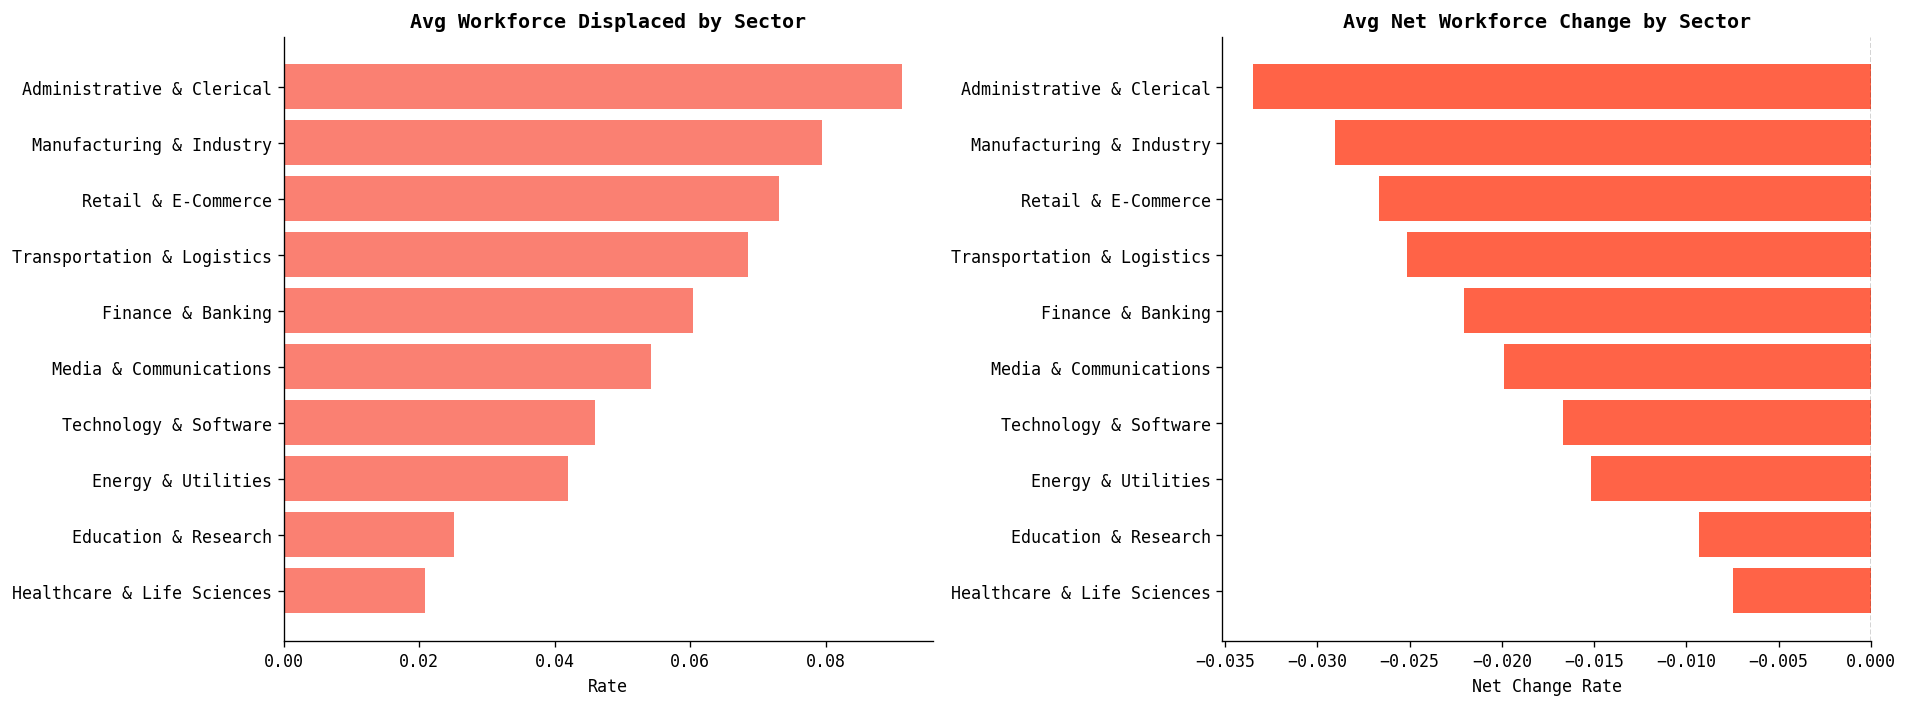

In [17]:
sector_agg = df.groupby('industry_sector').agg(
    avg_displaced=('pct_sector_workforce_displaced', 'mean'),
    avg_risk=('sector_automation_risk_score', 'mean'),
    avg_wage_premium=('ai_skill_wage_premium_pct', 'mean'),
    avg_net_change=('net_workforce_change_pct', 'mean')
).sort_values('avg_displaced', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

colors = ['tomato' if x < 0 else 'steelblue' for x in sector_agg['avg_net_change']]
axes[0].barh(sector_agg.index, sector_agg['avg_displaced'], color='salmon', label='Displaced')
axes[0].set_title('Avg Workforce Displaced by Sector', fontweight='bold')
axes[0].set_xlabel('Rate')

axes[1].barh(sector_agg.index, sector_agg['avg_net_change'], color=colors)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Avg Net Workforce Change by Sector', fontweight='bold')
axes[1].set_xlabel('Net Change Rate')

plt.tight_layout()
plt.show()

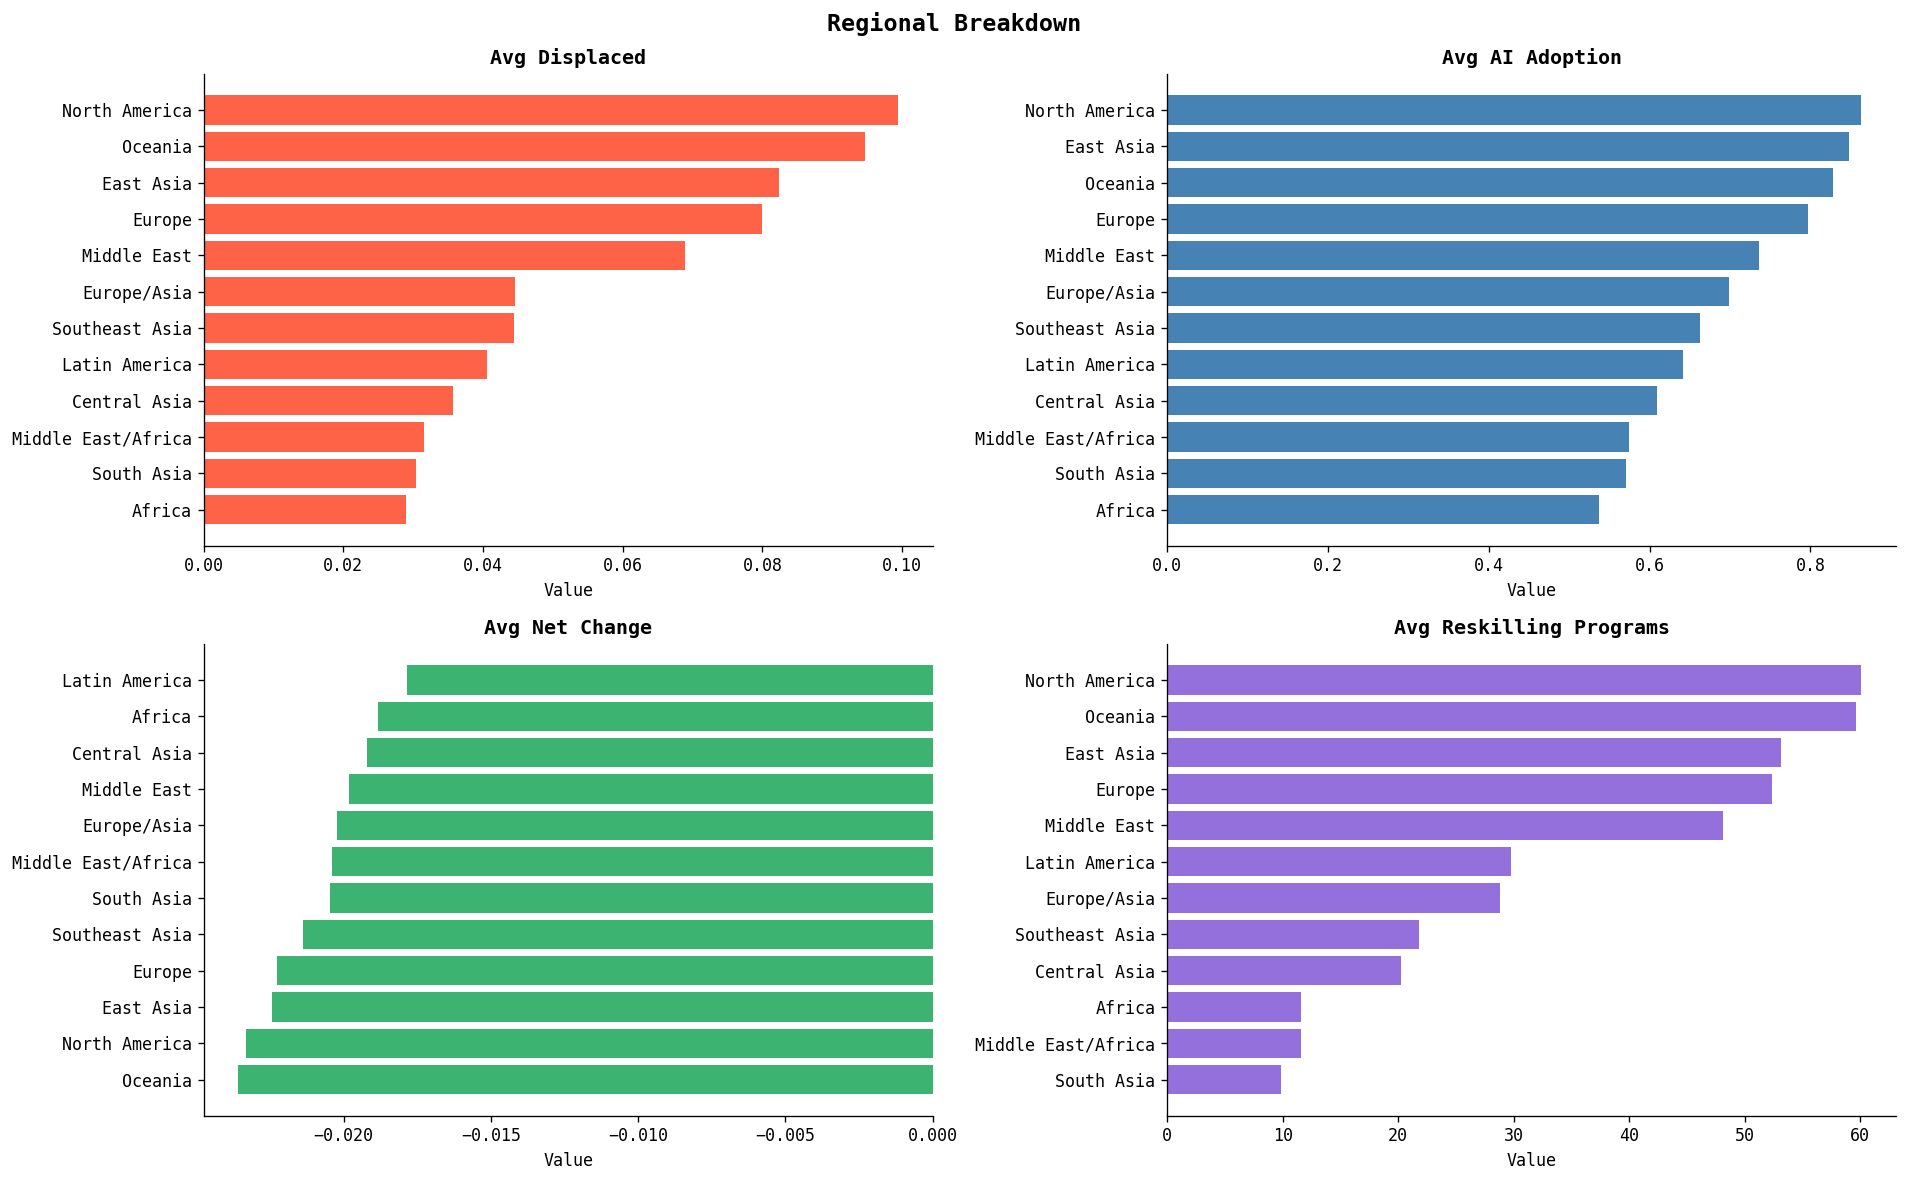

In [18]:
region_agg = df.groupby('region').agg(
    avg_displaced=('pct_sector_workforce_displaced', 'mean'),
    avg_ai_adoption=('ai_adoption_index', 'mean'),
    avg_net_change=('net_workforce_change_pct', 'mean'),
    avg_reskilling=('reskilling_programs_count', 'mean')
).sort_values('avg_displaced', ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics = ['avg_displaced', 'avg_ai_adoption', 'avg_net_change', 'avg_reskilling']
titles  = ['Avg Displaced', 'Avg AI Adoption', 'Avg Net Change', 'Avg Reskilling Programs']
palette = ['tomato', 'steelblue', 'mediumseagreen', 'mediumpurple']

for ax, metric, title, color in zip(axes.flat, metrics, titles, palette):
    data = region_agg[metric].sort_values(ascending=True)
    ax.barh(data.index, data.values, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Value')

plt.suptitle('Regional Breakdown', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

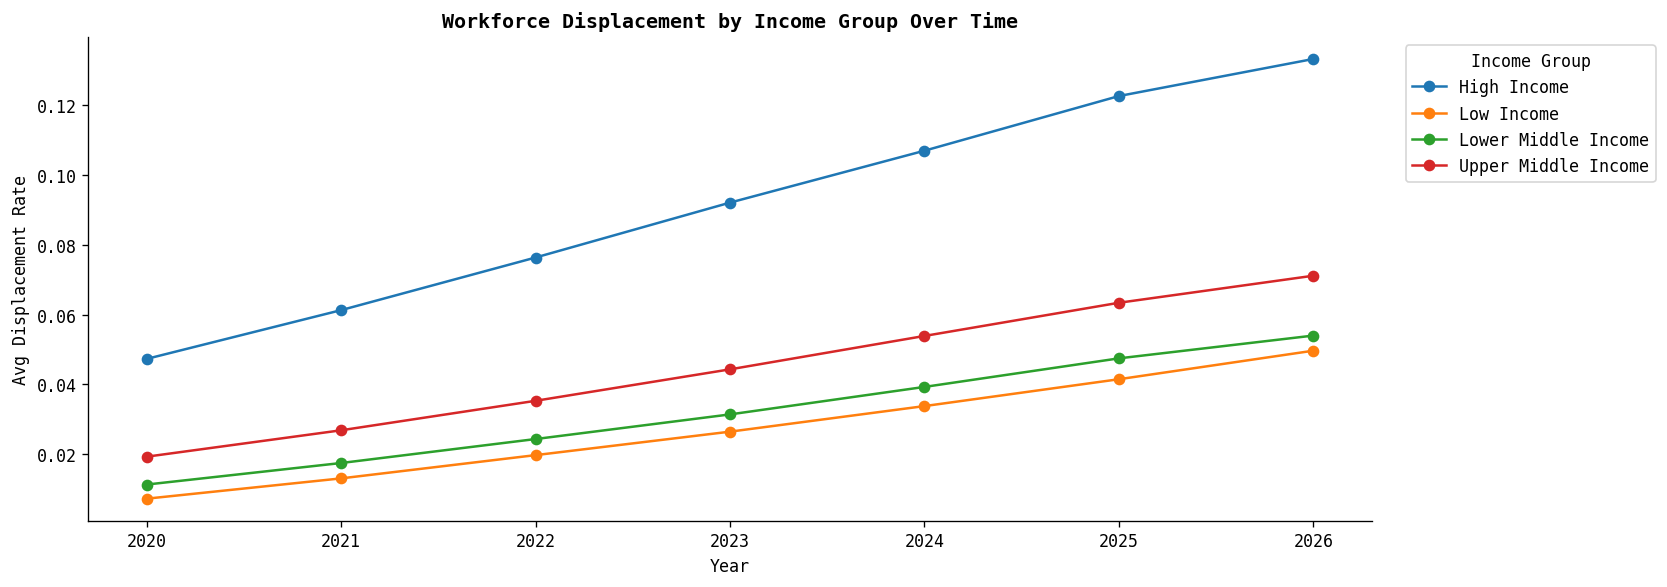

In [19]:
income_pivot = df.groupby(['income_group', 'year'])['pct_sector_workforce_displaced'].mean().unstack('year')
fig, ax = plt.subplots(figsize=(14, 5))
income_pivot.T.plot(ax=ax, marker='o')
ax.set_title('Workforce Displacement by Income Group Over Time', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Avg Displacement Rate')
ax.legend(title='Income Group', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

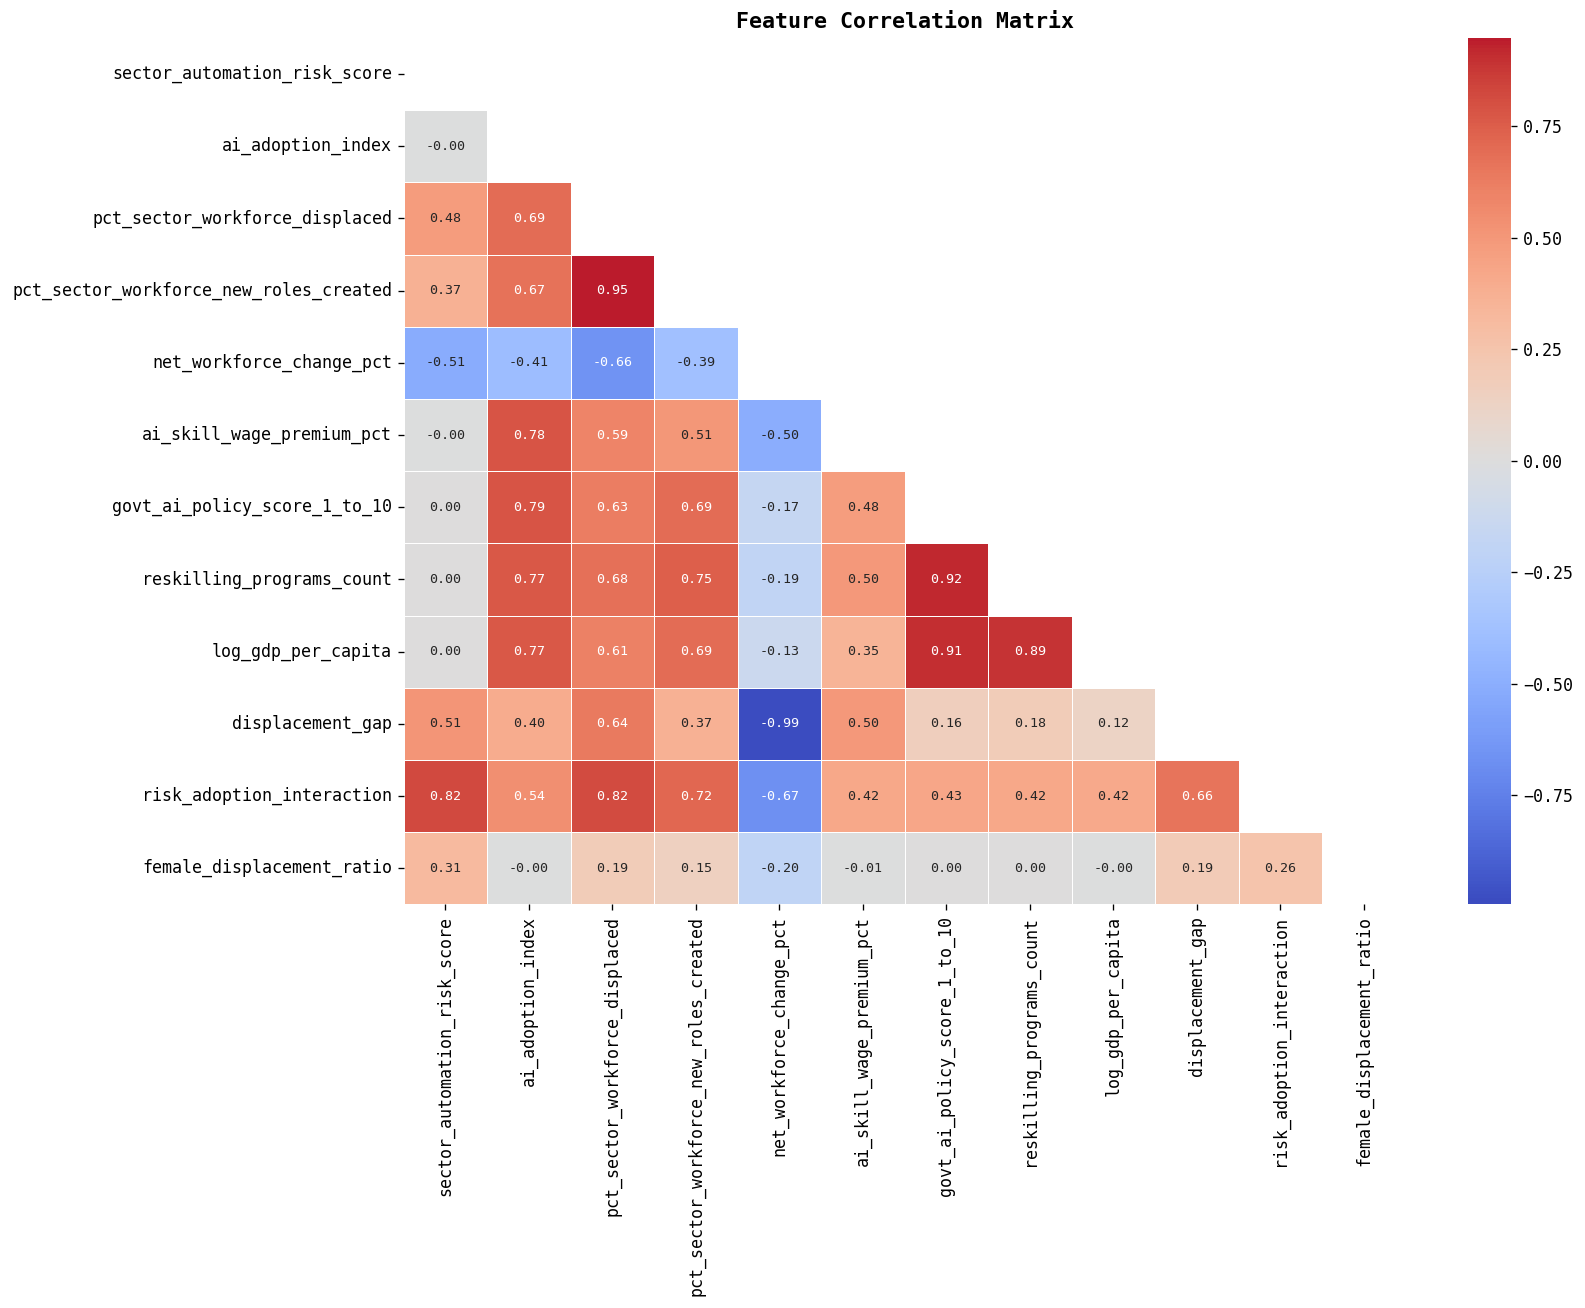

In [20]:
corr_cols = [
    'sector_automation_risk_score', 'ai_adoption_index', 'pct_sector_workforce_displaced',
    'pct_sector_workforce_new_roles_created', 'net_workforce_change_pct',
    'ai_skill_wage_premium_pct', 'govt_ai_policy_score_1_to_10',
    'reskilling_programs_count', 'log_gdp_per_capita', 'displacement_gap',
    'risk_adoption_interaction', 'female_displacement_ratio'
]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

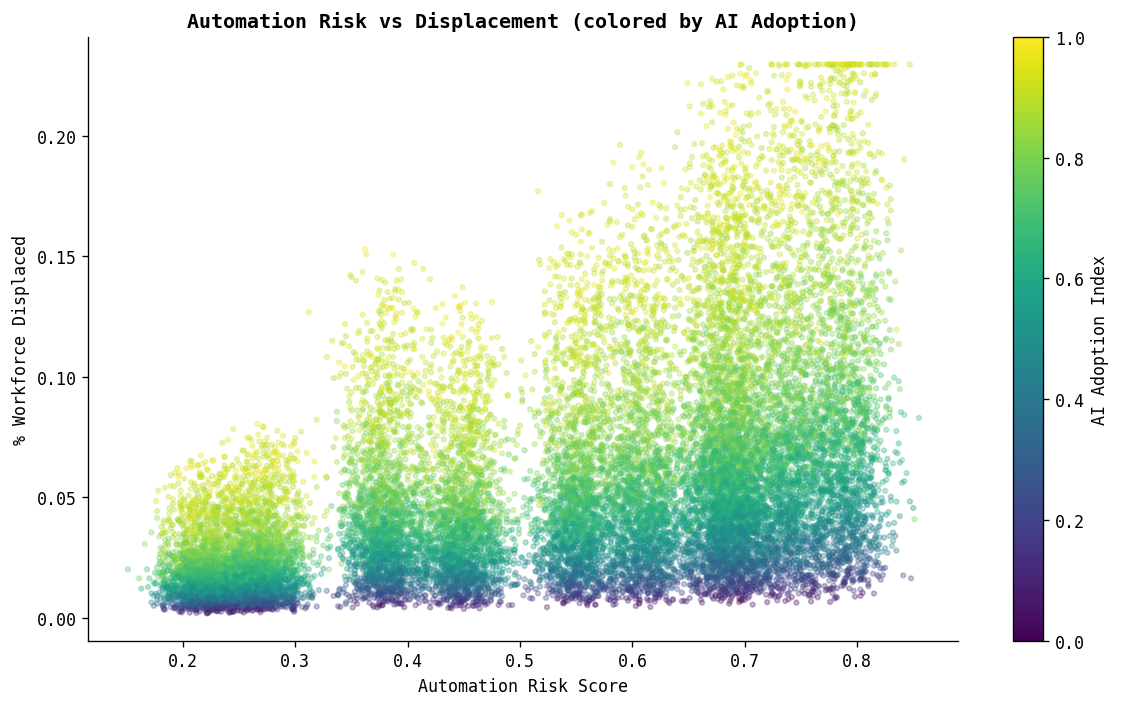

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    df['sector_automation_risk_score'],
    df['pct_sector_workforce_displaced'],
    c=df['ai_adoption_index'],
    cmap='viridis', alpha=0.3, s=8
)
sc = ax.scatter(
    [], [], c=[], cmap='viridis', vmin=df['ai_adoption_index'].min(),
    vmax=df['ai_adoption_index'].max()
)
plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=ax, label='AI Adoption Index')
ax.set_xlabel('Automation Risk Score')
ax.set_ylabel('% Workforce Displaced')
ax.set_title('Automation Risk vs Displacement (colored by AI Adoption)', fontweight='bold')
plt.tight_layout()
plt.show()

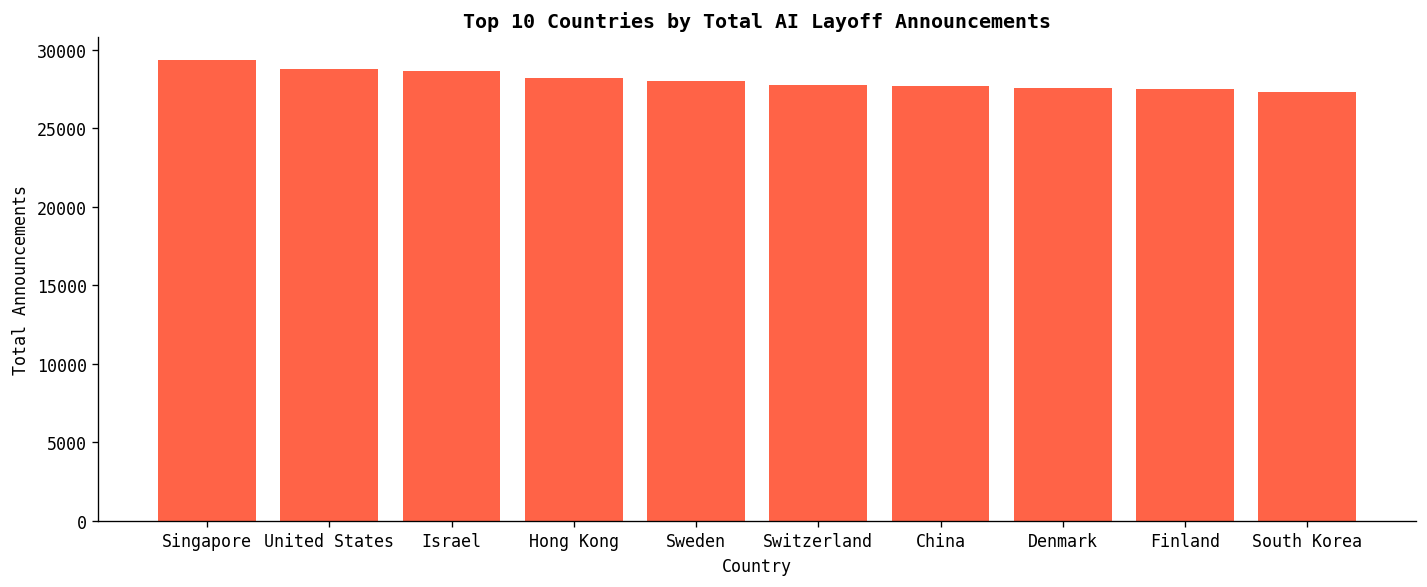

In [22]:
top10 = (
    df.groupby('country')['ai_cited_layoff_announcements']
    .sum().nlargest(10).reset_index()
)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top10['country'], top10['ai_cited_layoff_announcements'], color='tomato')
ax.set_title('Top 10 Countries by Total AI Layoff Announcements', fontweight='bold')
ax.set_ylabel('Total Announcements')
ax.set_xlabel('Country')
plt.tight_layout()
plt.show()

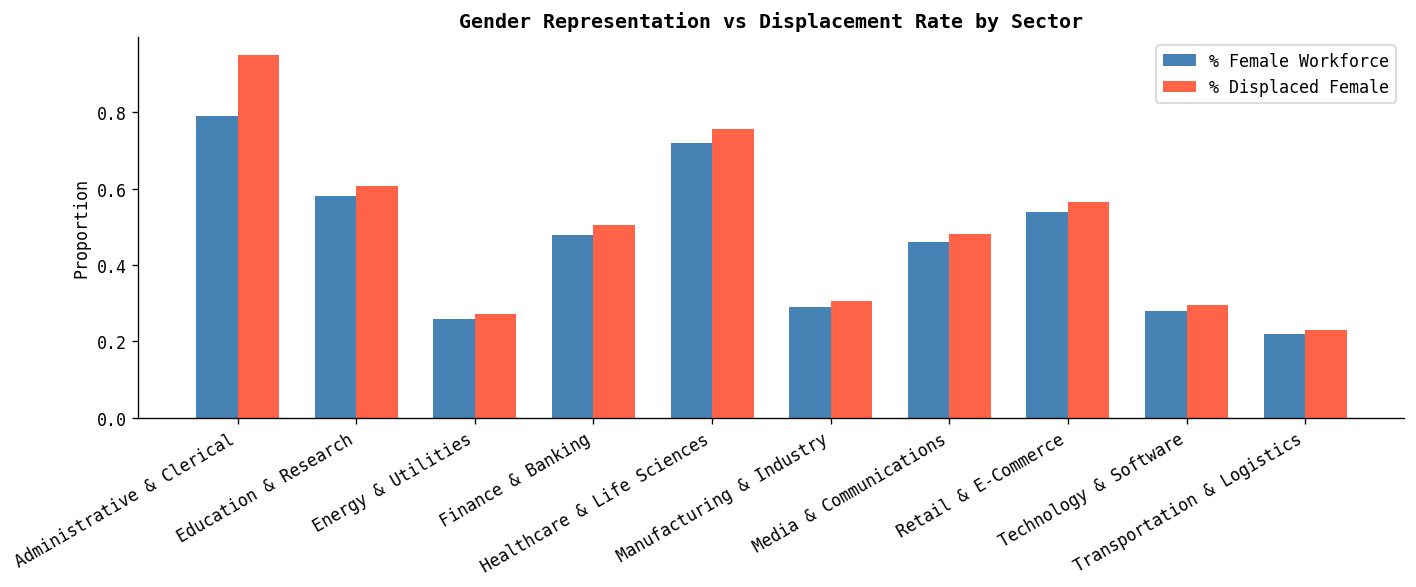

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))
female_sector = df.groupby('industry_sector')[['pct_workforce_female', 'pct_displaced_roles_female']].mean()
x = np.arange(len(female_sector))
width = 0.35
ax.bar(x - width/2, female_sector['pct_workforce_female'], width, label='% Female Workforce', color='steelblue')
ax.bar(x + width/2, female_sector['pct_displaced_roles_female'], width, label='% Displaced Female', color='tomato')
ax.set_xticks(x)
ax.set_xticklabels(female_sector.index, rotation=30, ha='right')
ax.set_title('Gender Representation vs Displacement Rate by Sector', fontweight='bold')
ax.set_ylabel('Proportion')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Modelling — Predicting Workforce Displacement Rate

In [24]:
TARGET = 'pct_sector_workforce_displaced'

FEATURES = [
    'sector_automation_risk_score', 'ai_adoption_index', 'ai_tool_adoption_pct',
    'log_gdp_per_capita', 'ai_skill_wage_premium_pct',
    'govt_ai_policy_score_1_to_10', 'reskilling_programs_count',
    'pct_workforce_female', 'year', 'quarter',
    'risk_adoption_interaction', 'female_displacement_ratio',
    'region_enc', 'income_group_enc', 'industry_sector_enc'
]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (16640, 15) | Test: (4160, 15)


In [25]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'fitted': model, 'y_pred': y_pred}

models = {
    'Ridge Regression'   : Ridge(alpha=1.0),
    'Random Forest'      : RandomForestRegressor(n_estimators=200, max_depth=10, random_state=SEED, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=SEED),
    'XGBoost'            : xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8,
                                            colsample_bytree=0.8, random_state=SEED, verbosity=0)
}

results = []
for name, model in models.items():
    res = evaluate_model(name, model, X_train, y_train, X_test, y_test)
    results.append(res)
    print(f'{name:25s}  RMSE={res["RMSE"]:.5f}  MAE={res["MAE"]:.5f}  R2={res["R2"]:.4f}')

results_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ('fitted', 'y_pred')} for r in results])
results_df

Ridge Regression           RMSE=0.01523  MAE=0.01088  R2=0.8861
Random Forest              RMSE=0.00956  MAE=0.00642  R2=0.9551
Gradient Boosting          RMSE=0.00885  MAE=0.00598  R2=0.9615
XGBoost                    RMSE=0.00868  MAE=0.00590  R2=0.9630


,Model,RMSE,MAE,R2
0,Ridge Regression,0.0152,0.0109,0.8861
1,Random Forest,0.0096,0.0064,0.9551
2,Gradient Boosting,0.0089,0.0060,0.9615
3,XGBoost,0.0087,0.0059,0.9630


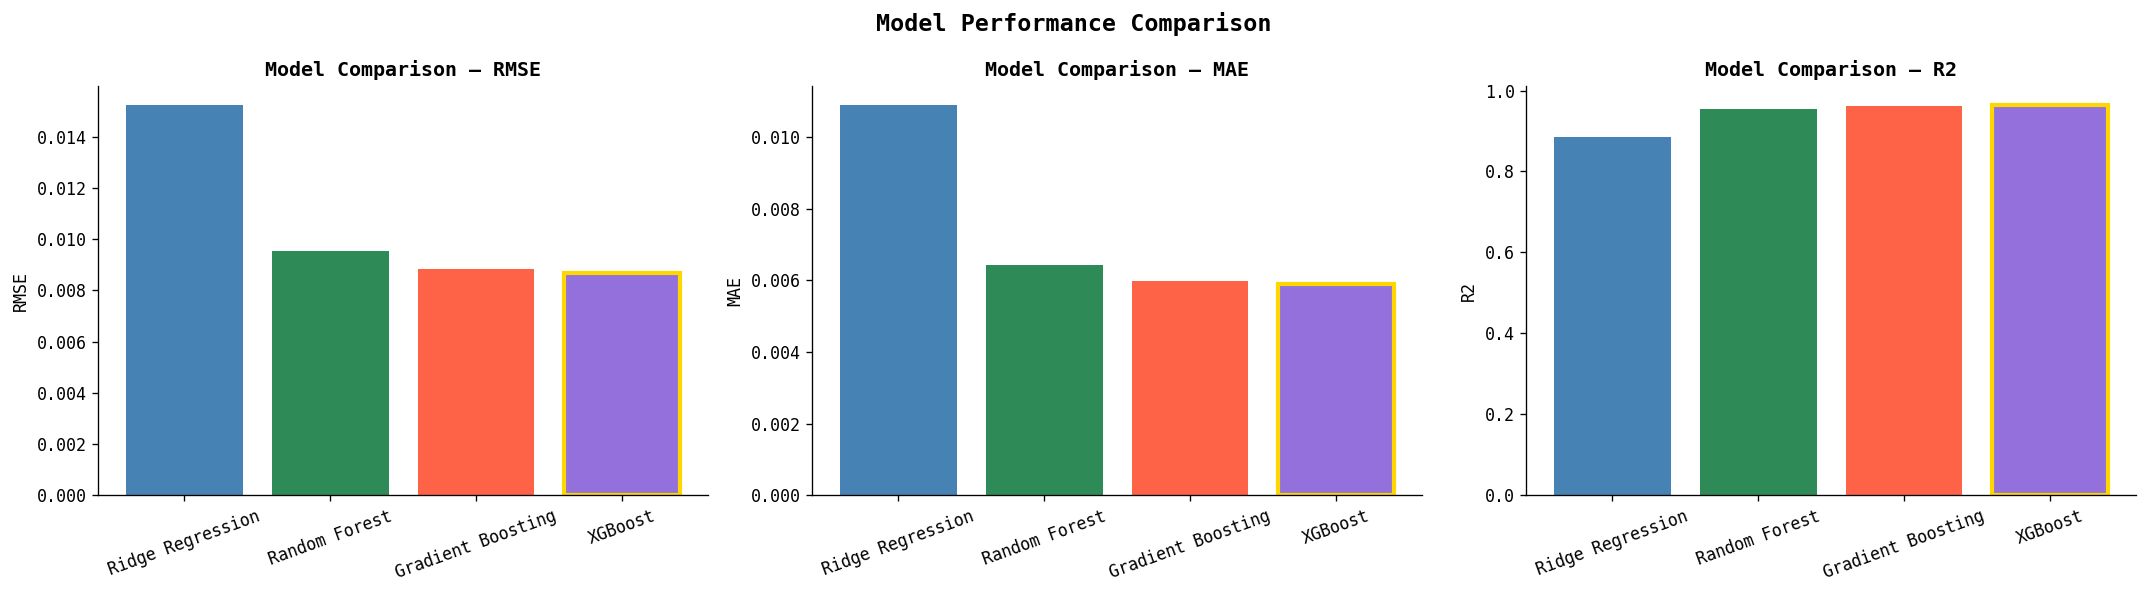

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for metric, ax in zip(['RMSE', 'MAE', 'R2'], axes):
    bars = ax.bar(results_df['Model'], results_df[metric],
                  color=['steelblue', 'seagreen', 'tomato', 'mediumpurple'])
    ax.set_title(f'Model Comparison — {metric}', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    best_idx = results_df[metric].idxmin() if metric != 'R2' else results_df[metric].idxmax()
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

plt.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Best model: XGBoost  R2=0.9630


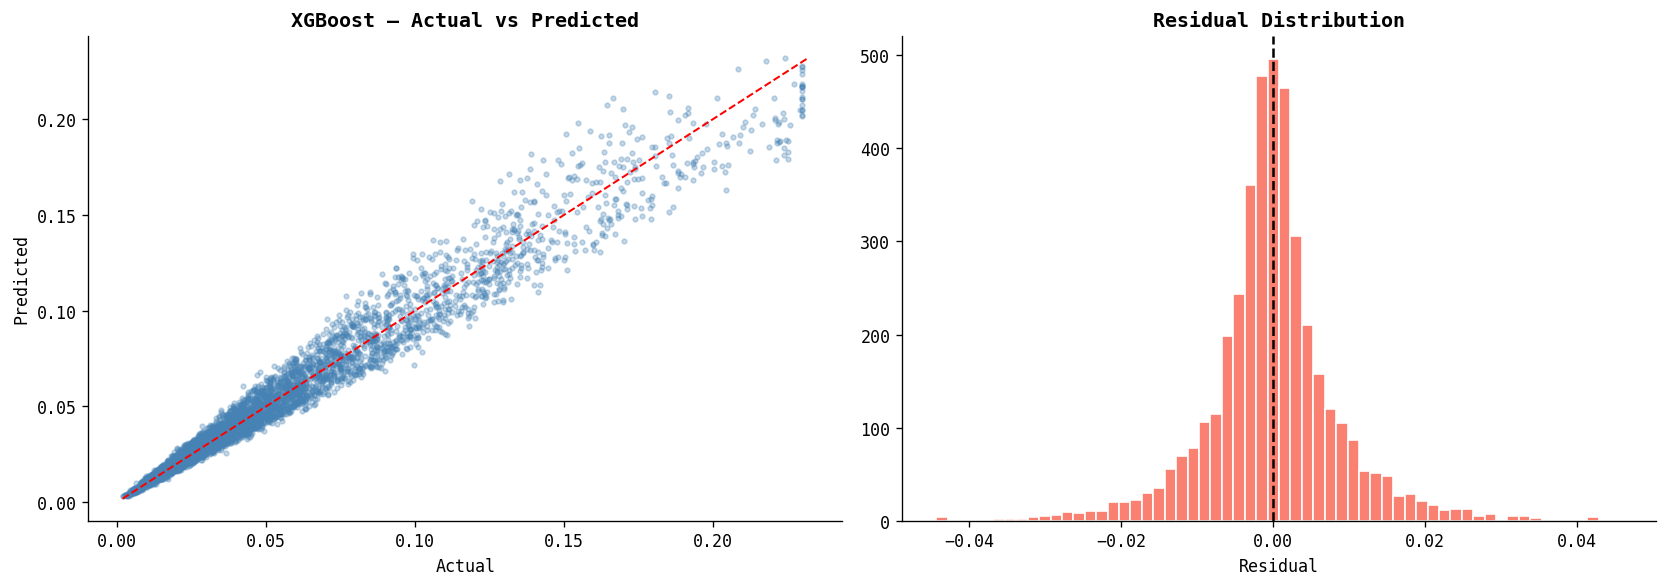

In [27]:
best_result = max(results, key=lambda x: x['R2'])
best_model  = best_result['fitted']
y_pred_best = best_result['y_pred']
print(f'Best model: {best_result["Model"]}  R2={best_result["R2"]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.3, s=8, color='steelblue')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.2)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'{best_result["Model"]} — Actual vs Predicted', fontweight='bold')

residuals = y_test - y_pred_best
axes[1].hist(residuals, bins=60, color='salmon', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

## 7. Feature Importance & SHAP Analysis

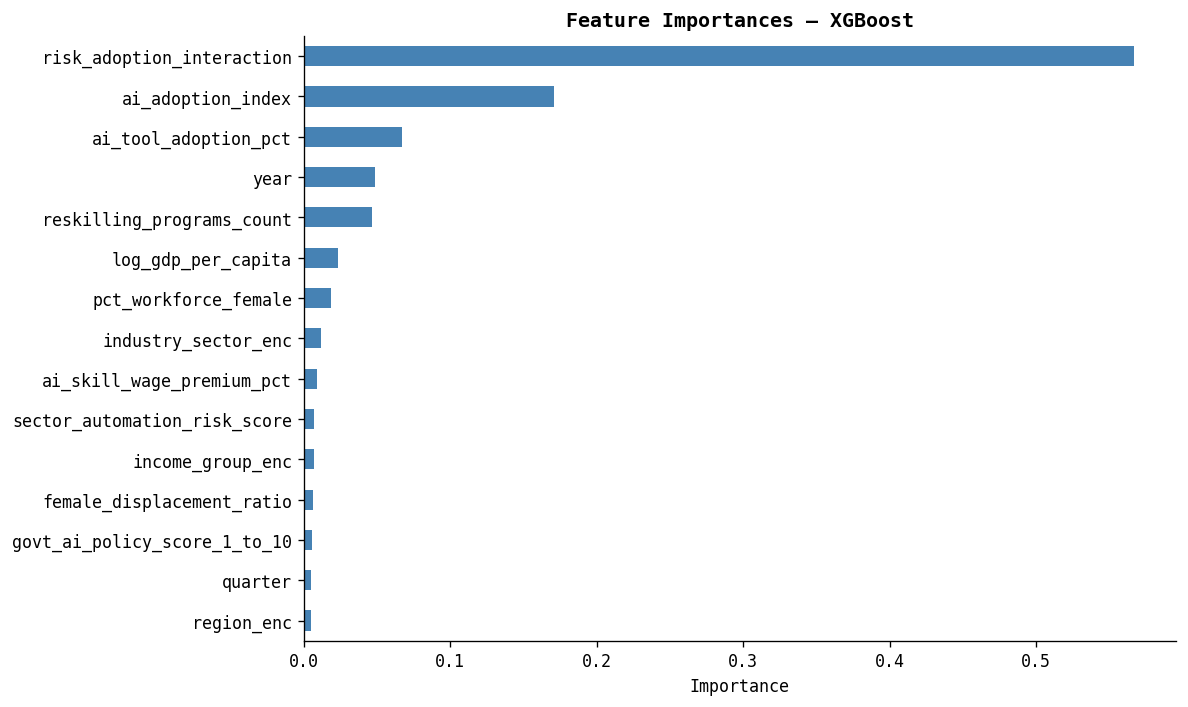

In [28]:
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values(ascending=True)
    fig, ax = plt.subplots(figsize=(10, 6))
    fi.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Feature Importances — {best_result["Model"]}', fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

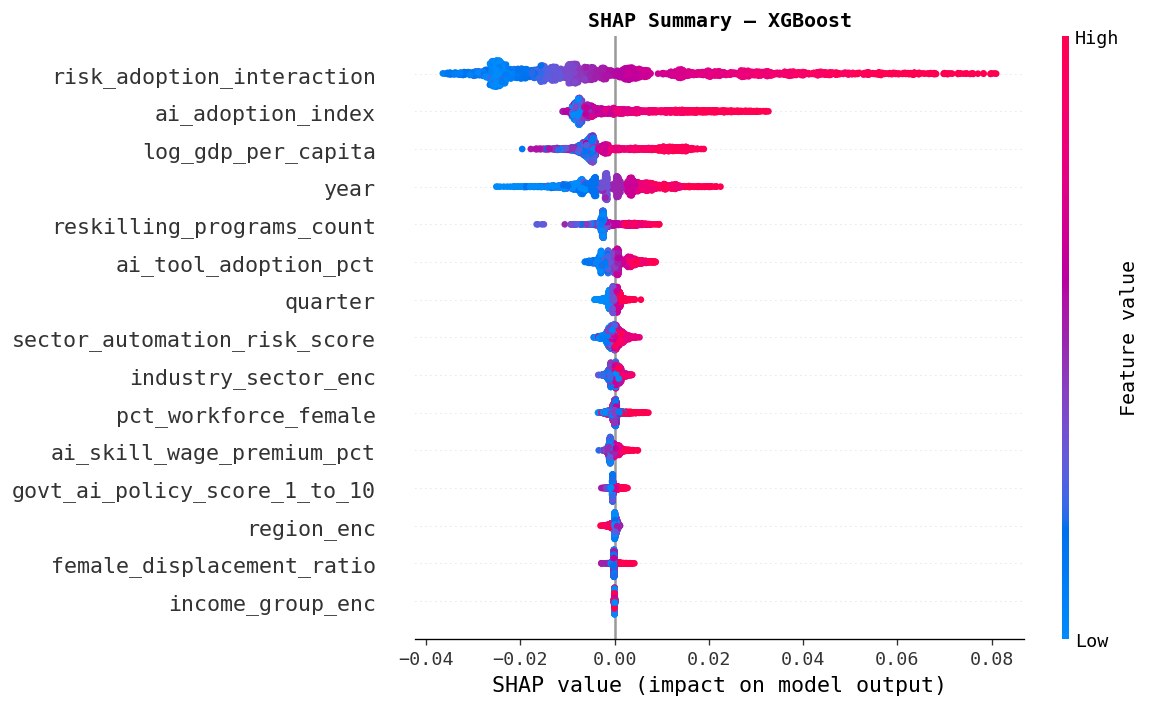

In [29]:
sample_size = min(2000, len(X_test))
X_shap = X_test.sample(sample_size, random_state=SEED)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES, show=False, plot_size=(10, 6))
plt.title(f'SHAP Summary — {best_result["Model"]}', fontweight='bold')
plt.tight_layout()
plt.show()

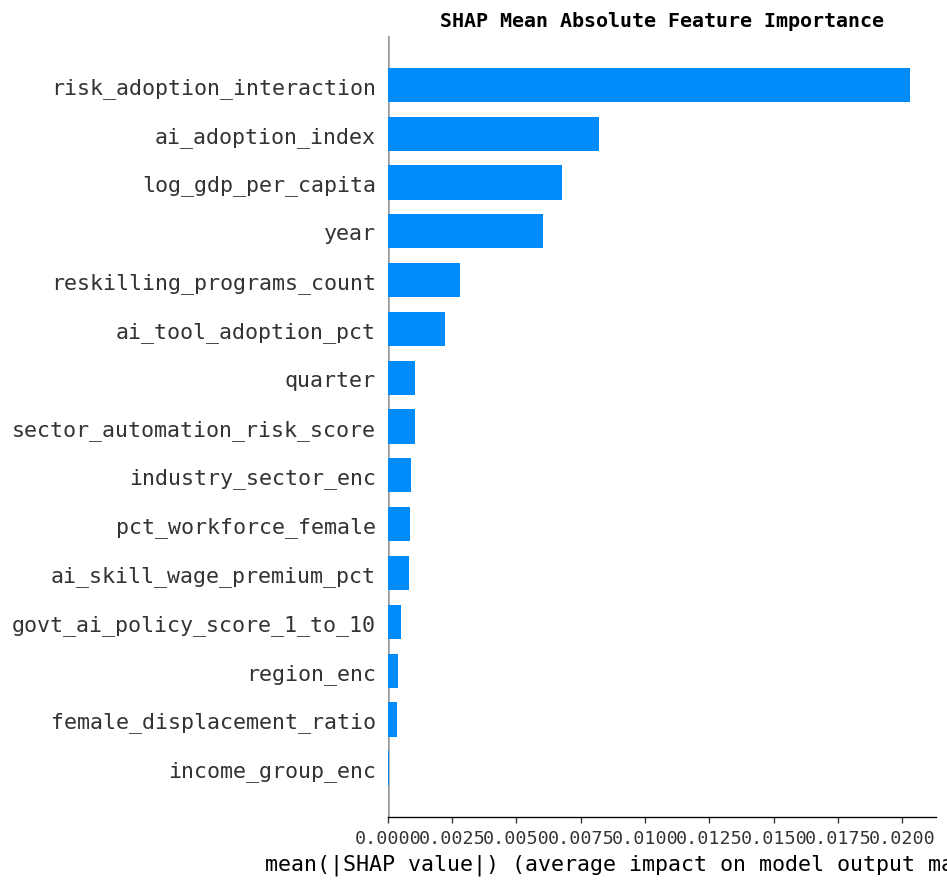

In [30]:
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_shap, feature_names=FEATURES, plot_type='bar', show=False)
plt.title('SHAP Mean Absolute Feature Importance', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Cross-Validation & Generalisation

Ridge      | 5-Fold R2: 0.8475 ± 0.0502
RF         | 5-Fold R2: 0.9373 ± 0.0159
XGBoost    | 5-Fold R2: 0.9493 ± 0.0127


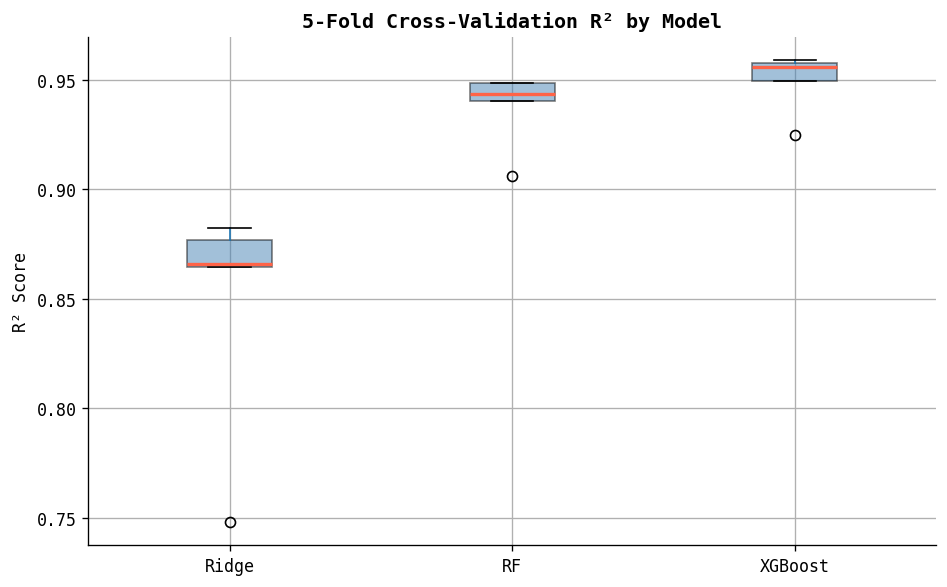

In [31]:
cv_models = {
    'Ridge'   : Ridge(alpha=1.0),
    'RF'      : RandomForestRegressor(n_estimators=100, max_depth=8, random_state=SEED, n_jobs=-1),
    'XGBoost' : xgb.XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1,
                                  random_state=SEED, verbosity=0)
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:10s} | 5-Fold R2: {scores.mean():.4f} ± {scores.std():.4f}')

cv_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(figsize=(8, 5))
cv_df.boxplot(ax=ax, patch_artist=True,
              boxprops=dict(facecolor='steelblue', alpha=0.5),
              medianprops=dict(color='tomato', linewidth=2))
ax.set_title('5-Fold Cross-Validation R² by Model', fontweight='bold')
ax.set_ylabel('R² Score')
plt.tight_layout()
plt.show()

## 9. Analytical Summaries

In [32]:
print('=== TOP 10 COUNTRIES BY DISPLACEMENT RATE ===')
df.groupby('country')['pct_sector_workforce_displaced'].mean().nlargest(10)

=== TOP 10 COUNTRIES BY DISPLACEMENT RATE ===


country
Singapore       0.1062
United States   0.1037
Denmark         0.1034
Switzerland     0.1031
Finland         0.1030
Sweden          0.1028
Norway          0.1023
Israel          0.1017
Netherlands     0.1010
Hong Kong       0.1007
Name: pct_sector_workforce_displaced, dtype: float64

In [33]:
print('=== SECTOR NET CHANGE SUMMARY ===')
df.groupby('industry_sector')[['pct_sector_workforce_displaced', 'net_workforce_change_pct', 'ai_skill_wage_premium_pct']].mean().round(4)

=== SECTOR NET CHANGE SUMMARY ===


,pct_sector_workforce_displaced,net_workforce_change_pct,ai_skill_wage_premium_pct
industry_sector,,,
Administrative & Clerical,0.0912,-0.0335,0.3614
Education & Research,0.0252,-0.0093,0.3629
Energy & Utilities,0.0420,-0.0152,0.3623
Finance & Banking,0.0603,-0.0220,0.3624
Healthcare & Life Sciences,0.0209,-0.0075,0.3611
Manufacturing & Industry,0.0794,-0.0291,0.3609
Media & Communications,0.0541,-0.0199,0.3611
Retail & E-Commerce,0.0731,-0.0267,0.3614
Technology & Software,0.0460,-0.0167,0.3604


In [34]:
print('=== RESKILLING ADEQUACY BY INCOME GROUP ===')
df.groupby('income_group')[['reskilling_programs_count', 'pct_sector_workforce_displaced', 'reskilling_per_displacement']].mean().round(4)

=== RESKILLING ADEQUACY BY INCOME GROUP ===


,reskilling_programs_count,pct_sector_workforce_displaced,reskilling_per_displacement
income_group,,,
High Income,59.3485,0.0882,935.8692
Low Income,3.4577,0.0256,219.2392
Lower Middle Income,11.4811,0.0305,573.1500
Upper Middle Income,28.8234,0.0429,973.4296


In [35]:
print('=== GOVT POLICY vs DISPLACEMENT CORRELATION ===')
corr_val = df[['govt_ai_policy_score_1_to_10', 'pct_sector_workforce_displaced']].corr().iloc[0, 1]
print(f'Pearson r: {corr_val:.4f}')

=== GOVT POLICY vs DISPLACEMENT CORRELATION ===
Pearson r: 0.6254


## 10. Export Cleaned & Engineered Dataset

In [36]:
EXPORT_PATH = 'ai_workforce_displacement_processed.csv'
df.to_csv(EXPORT_PATH, index=False)
print(f'Exported to: {EXPORT_PATH}')
print(f'Final shape: {df.shape}')
print(f'Columns    : {df.columns.tolist()}')

Exported to: ai_workforce_displacement_processed.csv
Final shape: (20800, 34)
Columns    : ['record_id', 'country', 'iso3_code', 'region', 'income_group', 'year', 'quarter', 'quarter_label', 'industry_sector', 'sector_automation_risk_score', 'gdp_per_capita_usd', 'ai_adoption_index', 'pct_sector_workforce_displaced', 'pct_sector_workforce_new_roles_created', 'net_workforce_change_pct', 'ai_cited_layoff_announcements', 'ai_skill_wage_premium_pct', 'pct_workforce_female', 'pct_displaced_roles_female', 'reskilling_programs_count', 'govt_ai_policy_score_1_to_10', 'ai_tool_adoption_pct', 'displacement_gap', 'log_gdp_per_capita', 'log_layoff_announcements', 'risk_adoption_interaction', 'female_displacement_ratio', 'reskilling_per_displacement', 'year_quarter', 'high_risk_sector', 'net_change_flag', 'region_enc', 'income_group_enc', 'industry_sector_enc']


In [37]:
import joblib
joblib.dump(best_model, 'best_displacement_model.pkl')
print(f'Model saved: best_displacement_model.pkl  [{best_result["Model"]}]')

Model saved: best_displacement_model.pkl  [XGBoost]


## 11. Pipeline Summary

In [38]:
print('=' * 60)
print('AI WORKFORCE DISPLACEMENT — PIPELINE SUMMARY')
print('=' * 60)
print(f'  Raw records          : {len(df_raw):,}')
print(f'  Cleaned records      : {len(df):,}')
print(f'  Features engineered  : {len(new_cols)}')
print(f'  Models trained       : {len(models)}')
print(f'  Best model           : {best_result["Model"]}')
print(f'  Best R²              : {best_result["R2"]:.4f}')
print(f'  Best RMSE            : {best_result["RMSE"]:.5f}')
print(f'  Best MAE             : {best_result["MAE"]:.5f}')
print('=' * 60)

AI WORKFORCE DISPLACEMENT — PIPELINE SUMMARY
  Raw records          : 20,800
  Cleaned records      : 20,800
  Features engineered  : 9
  Models trained       : 4
  Best model           : XGBoost
  Best R²              : 0.9630
  Best RMSE            : 0.00868
  Best MAE             : 0.00590
